# Fabrication Analysis — LLM Eval Pipeline (V1 vs V2)

Runs the 14 confirmed fabrication cases through the `src/llm_eval_by_llm/` pipeline:

| Phase | Module | Output |
|-------|--------|--------|
| 1 | `source_document_feature_extraction_v3_simple.py` | `data/processed/source_doc_features_v3_simple/fab_case_*.json` |
| 3 | `deepeval_multi_model_pipeline.py` (LLM judge) | `data/processed/deepeval_runs/fab_v1_v2/` |
| — | Comparison figures | `reports/fab_v1_v2_*.png` |

In [1]:
import os, sys, json, re, time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from docx import Document
from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT     = Path(os.getenv('PROJECT_ROOT',
    r'C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center'
    r'\Documents\GitHub\llm_summarization_br_ca'))
DATA_PRIVATE     = Path(os.getenv('DATA_PRIVATE_DIR', r'C:\Users\jamesr4\loc\data_private'))
sys.path.insert(0, str(PROJECT_ROOT))

# ── Pipeline module imports ───────────────────────────────────────────────────
sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'llm_eval_by_llm'))
from source_document_feature_extraction_v3_simple import (
    ELEMENT_TRIPLES, compute_text_features,
    annotation_outcome, is_correct, is_fabrication,
)
from deepeval_multi_model_pipeline import (
    ELEMENTS, encode_annotation, compute_run_metrics, call_llm,
)

# ── Paths ─────────────────────────────────────────────────────────────────────
OCR_CACHE    = DATA_PRIVATE / 'ocr_cache'
MAPPING_CSV  = DATA_PRIVATE / 'breast_bot_deidentified' / 'case_id_mapping.csv'
FAB_XLSX     = DATA_PRIVATE / 'raw' / 'ai_fabrications_dataset.xlsx'
V1_CSV       = DATA_PRIVATE / 'raw' / 'v1_summary_paths.csv'
V2_CSV       = DATA_PRIVATE / 'raw' / 'v2_summary_paths.csv'
GT_XLSX      = DATA_PRIVATE / 'raw' / 'merged_llm_summary_validation_datasheet_identified.xlsx'

FEAT_OUT     = PROJECT_ROOT / 'data' / 'processed' / 'source_doc_features_v3_simple'
DEEPEVAL_OUT = PROJECT_ROOT / 'data' / 'processed' / 'deepeval_runs' / 'fab_v1_v2'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
CACHE_FILE   = PROJECT_ROOT / 'fabrication_analysis' / 'cache' / 'llm_judge_cache.json'

for d in [FEAT_OUT, DEEPEVAL_OUT, REPORTS_DIR, CACHE_FILE.parent]:
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Imports OK')
print(f'GT_XLSX      : {GT_XLSX}  exists={GT_XLSX.exists()}')
print(f'FEAT_OUT     : {FEAT_OUT}')
print(f'DEEPEVAL_OUT : {DEEPEVAL_OUT}')

Imports OK
GT_XLSX      : C:\Users\jamesr4\loc\data_private\raw\merged_llm_summary_validation_datasheet_identified.xlsx  exists=True
FEAT_OUT     : C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\data\processed\source_doc_features_v3_simple
DEEPEVAL_OUT : C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\data\processed\deepeval_runs\fab_v1_v2


## Phase 1 — Source Document Feature Extraction (`source_document_feature_extraction_v3_simple`)

In [2]:
# ── Load fabrication dataset ──────────────────────────────────────────────────
_SURGEON_MAP = {
    'el tamer': 'el tamer', 'el-tamer': 'el tamer',
    'sacchini': 'sacchini', 'giannakou': 'giannakou',
    'montagna': 'montag', 'montag': 'montag', 'lisa allen': 'allen',
}
def _norm(s):
    return _SURGEON_MAP.get(str(s).strip().lower(), str(s).strip().lower())

fab      = pd.read_excel(FAB_XLSX)
ai_cols  = [c for c in fab.columns if c.endswith('_status_ai')]
for c in ai_cols:
    fab[c] = pd.to_numeric(fab[c], errors='coerce')
fab['surgeon_last'] = fab['surgeon'].str.split(',').str[0].str.strip()
fab['surgeon_norm'] = fab['surgeon_last'].apply(_norm)
fab['fab_features'] = fab.apply(
    lambda r: [c.replace('_status_ai', '') for c in ai_cols if r[c] == 3], axis=1
)

mapping = pd.read_csv(MAPPING_CSV)
mapping['surgeon_norm']    = mapping['surgeon'].apply(_norm)
mapping['folder_initials'] = mapping['case_folder'].str.split('_').str[1].str.upper()
rep = (
    mapping.dropna(subset=['original_path'])
    .drop_duplicates(subset=['surgeon_norm', 'folder_initials'])
    [['surgeon_norm', 'folder_initials', 'case_folder']]
)
df_fab = fab.merge(rep, left_on=['surgeon_norm', 'patient_initials'],
                   right_on=['surgeon_norm', 'folder_initials'], how='left')

# ── Load validation datasheet (sheet: all_cases) ─────────────────────────────
val_df = pd.read_excel(GT_XLSX, sheet_name='all_cases')
val_df['mrn'] = pd.to_numeric(val_df['mrn'], errors='coerce')
val_df = val_df.dropna(subset=['mrn'])
val_df['mrn'] = val_df['mrn'].astype(int)
print(f'Validation sheet: {len(val_df)} rows, 14-fab coverage: '
      f'{sum(m in val_df["mrn"].values for m in fab["mrn"].values)}/{len(fab)}')

# ── Build per-case source text from OCR cache ─────────────────────────────────
fab_cases = []
for _, row in df_fab.iterrows():
    cf   = str(row.get('case_folder', ''))
    mrn  = int(row['mrn'])
    docs = mapping[mapping['case_folder'] == cf][['case_id', 'original_filename']].copy()

    texts = []
    for _, d in docs.iterrows():
        cache = OCR_CACHE / f"{d['case_id']}.txt"
        if cache.exists():
            texts.append(f"[{d['original_filename']}]\n"
                         + cache.read_text(encoding='utf-8', errors='ignore'))
    ocr_text = '\n\n'.join(texts)

    # Match to validation row
    vrow = val_df[val_df['mrn'] == mrn]

    # Build element annotation outcomes using v3_simple's logic
    elements_data = {}
    for col_prefix, display_name in ELEMENT_TRIPLES:
        src_col = f'{col_prefix}_source'
        ai_col  = f'{col_prefix}_ai'
        src_val = vrow[src_col].values[0]  if (not vrow.empty and src_col in vrow) else None
        ai_val  = vrow[ai_col].values[0]   if (not vrow.empty and ai_col  in vrow) else None
        outcome = annotation_outcome(src_val, ai_val)
        elements_data[display_name] = {
            'source_present': int(src_val) if pd.notna(src_val) else None,
            'ai_annotation':  ai_val if pd.notna(ai_val) else None,
            'ai_outcome':     outcome,
            'ai_correct':     is_correct(outcome),
            'ai_fabrication': is_fabrication(outcome),
        }

    text_feats = compute_text_features(ocr_text)
    record = {
        'mrn':           mrn,
        'case_folder':   cf,
        'fab_features':  row['fab_features'],
        'ocr_text':      ocr_text,
        'text_features': text_feats,
        'n_docs_cached': len(texts),
        'elements':      elements_data,
    }
    fab_cases.append(record)

    # Save to source_doc_features_v3_simple/ (pipeline format)
    out_path = FEAT_OUT / f'fab_case_{mrn}.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump({k: v for k, v in record.items() if k != 'ocr_text'},
                  f, indent=2, default=str)

    print(f'  {cf:<22}  docs={len(texts)}  chars={len(ocr_text):>7}  fab={row["fab_features"]}')

print(f'\nPhase 1 complete: {len(fab_cases)} cases → {FEAT_OUT}')

Validation sheet: 200 rows, 14-fab coverage: 14/14
  GM_XM_INV               docs=7  chars=  29809  fab=['invasive_component_size_pathology']
  DC_BF_invasive          docs=5  chars=  29425  fab=['histologic_diagnosis']
  LK_SW_INV               docs=6  chars=  26004  fab=['lesion_size']
  AT_RW_INV               docs=5  chars=  28982  fab=['receptor']
  MET_KS                  docs=4  chars=  16361  fab=['lesion_size']
  AH_UD_INV               docs=8  chars=  39172  fab=['lesion_size']
  ML_WY_INV               docs=8  chars=  34604  fab=['invasive_component_size_pathology']
  GM_DR_INV               docs=5  chars= 151328  fab=['receptor']
  KP_MM_INV               docs=4  chars=  27186  fab=['chronology_preserved']


  GP_MC_INV               docs=10  chars=  41181  fab=['biopsy_method']
  MET_MW                  docs=6  chars=  24889  fab=['workup_recommendation']
  MET_MM                  docs=5  chars=  27109  fab=['extent']
  MET_DM                  docs=6  chars=  52055  fab=['workup_recommendation']
  TM_FS_DCIS              docs=5  chars=  22485  fab=['lesion_size']

Phase 1 complete: 14 cases → C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\data\processed\source_doc_features_v3_simple


## Phase 3 — LLM Judge Evaluation (`deepeval_multi_model_pipeline` approach)
Uses GPT-4o as LLM judge to assign pipeline validation codes (1/2/3/N/A) to:
- **V1** narrative DOCX summaries (known to contain fabrications)
- **V2** structured JSON TXT summaries (v2 prompt with anti-fabrication constraints)

Outputs a validation sheet compatible with `compute_run_metrics`.

In [3]:
# ── Load v1 and v2 summaries ──────────────────────────────────────────────────
v1_paths = pd.read_csv(V1_CSV)
v2_paths = pd.read_csv(V2_CSV)

def read_docx(path_str):
    p = Path(path_str)
    if not p.exists():
        return ''
    try:
        return '\n'.join(para.text for para in Document(str(p)).paragraphs if para.text.strip())
    except Exception:
        return ''

def read_v2_json(path_str):
    p = Path(path_str)
    if not p.exists():
        return {}
    raw = p.read_text(encoding='utf-8', errors='ignore')
    raw = re.sub(r'^```[a-z]*\n?', '', raw.strip(), flags=re.MULTILINE)
    raw = re.sub(r'```$', '', raw.strip())
    try:
        return json.loads(raw)
    except Exception:
        return {'_raw': raw}

def v2_feature_text(parsed, feature_key):
    """Get a stringified value for a feature from v2 JSON, for the LLM judge."""
    for k, v in parsed.items():
        if feature_key.lower().replace('_', ' ') in k.lower() or \
           feature_key.lower() in k.lower().replace(' ', '_'):
            if isinstance(v, dict):
                return json.dumps(v)
            return str(v)
    return 'NOT FOUND IN SUMMARY'

summaries = {}
for case in fab_cases:
    mrn = case['mrn']
    v1r = v1_paths[v1_paths['mrn'] == mrn]
    v2r = v2_paths[v2_paths['mrn'] == mrn]
    summaries[mrn] = {
        'v1_text': read_docx(v1r['summary_path'].values[0]) if len(v1r) else '',
        'v2_json': read_v2_json(v2r['summary_path'].values[0]) if len(v2r) else {},
    }

print(f'Loaded summaries for {len(summaries)} cases')
for mrn, s in summaries.items():
    print(f'  MRN {mrn}  v1={len(s["v1_text"])}ch  v2_keys={list(s["v2_json"].keys())[:4]}')

Loaded summaries for 14 cases
  MRN 39089057  v1=4380ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 38138814  v1=3543ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39100822  v1=4426ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39091629  v1=5093ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39111396  v1=3315ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39095007  v1=3745ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39094834  v1=5139ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39092180  v1=3604ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39089385  v1=4426ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39102467  v1=4654ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39106459  v1=4210ch  v2_keys=['lesions', 'feature_9_chronology_preserved']
  MRN 39103258  v1=4357ch  v2_keys=['lesions', 'feature_9_chronology_preserved'

In [4]:
# ── LLM Judge system prompt ───────────────────────────────────────────────────
JUDGE_SYSTEM = """You are a clinical data quality auditor specializing in breast oncology.
You evaluate whether an AI-generated clinical summary correctly reports a specific feature
compared to what the source medical documents actually state.

Coding schema (must match human validation format):
  1    = CORRECT (TP) — feature present in source AND correctly reported
  2    = OMISSION (FN) — feature present in source BUT missed/omitted by summary
  3    = FABRICATION (FP) — summary reports a value that is NOT in source or conflicts with source
  "N/A" = TRUE NEGATIVE — feature absent from source AND summary correctly does not report it

Respond ONLY with valid JSON, exactly: {"annotation": <1|2|3|"N/A">, "confidence": 0.0-1.0, "reasoning": "..."}."""

ELEMENT_KEY_MAP = {
    'Lesion Size': 'lesion_size',
    'Lesion Laterality': 'lesion_laterality',
    'Lesion Location': 'lesion_location',
    'Calcifications / Asymmetry': 'calcifications_asymmetry',
    'Additional Enhancement (MRI)': 'additional_enhancement_mri',
    'Extent': 'extent',
    'Accurate Clip Placement': 'accurate_clip_placement',
    'Workup Recommendation': 'workup_recommendation',
    'Lymph Node': 'lymph_node',
    'Chronology Preserved': 'chronology_preserved',
    'Biopsy Method': 'biopsy_method',
    'Invasive Component Size (Pathology)': 'invasive_component_size',
    'Histologic Diagnosis': 'histologic_diagnosis',
    'Receptor Status': 'receptor_status',
}

def judge_summary(
    source_text: str,
    summary_text: str,
    element_display: str,
    source_present: int,
    cache: dict,
    cache_key: str,
) -> dict:
    if cache_key in cache:
        return cache[cache_key]

    user_msg = f"""CLINICAL ELEMENT: {element_display}
SOURCE PRESENT IN DOCUMENT: {source_present} (1=yes, 0=no)

SOURCE DOCUMENT TEXT (first 2500 chars):
---
{source_text[:2500]}
---

SUMMARY TEXT (excerpt):
---
{summary_text[:1500]}
---

Assign annotation code (1/2/3/N/A) for this element in this summary."""

    try:
        raw = call_llm('gpt-4o', JUDGE_SYSTEM, user_msg, temperature=0.0, max_tokens=256)
        # Strip markdown if present
        raw = re.sub(r'^```[a-z]*\n?', '', raw.strip(), flags=re.MULTILINE)
        raw = re.sub(r'```$', '', raw.strip())
        result = json.loads(raw)
    except Exception as e:
        result = {'annotation': None, 'confidence': 0.0, 'reasoning': str(e)}

    cache[cache_key] = result
    return result

print('LLM judge function ready')

LLM judge function ready


In [5]:
# ── Run LLM judge ONLY for confirmed fab features (v1 + v2) ──────────────────
# 14 cases × ~1-2 fab features × 2 versions ≈ 28-40 calls  (vs 392 for all)
judge_cache = json.loads(CACHE_FILE.read_text()) if CACHE_FILE.exists() else {}

# Build element lookup: feature_key → {elem dict}
ELEM_BY_KEY = {e['key']: e for e in ELEMENTS}

# Map from fab_dataset column names → ELEMENTS key
FAB_FEAT_TO_ELEM_KEY = {
    'lesion_size':                       'lesion_size',
    'laterality':                        'lesion_laterality',
    'lesion_location':                   'lesion_location',
    'calcifications_asymmetry':          'calcifications_asymmetry',
    'additional_enhancement_mri':        'additional_enhancement_mri',
    'extent':                            'extent',
    'accurate_clip_placement':           'accurate_clip_placement',
    'workup_recommendation':             'workup_recommendation',
    'lymph_node':                        'lymph_node',
    'chronology_preserved':              'chronology_preserved',
    'biopsy_method':                     'biopsy_method',
    'invasive_component_size_pathology': 'invasive_component_size',
    'histologic_diagnosis':              'histologic_diagnosis',
    'receptor':                          'receptor_status',
}

comp_rows = []
run_rows  = []

for case in fab_cases:
    mrn      = case['mrn']
    cf       = case['case_folder']
    ocr      = case['ocr_text']
    sums     = summaries[mrn]
    v1_text  = sums['v1_text']
    v2_json  = sums['v2_json']
    vrow     = val_df[val_df['mrn'] == mrn]

    print(f'MRN {mrn} ({cf}) — confirmed fabs: {case["fab_features"]}')

    run_row = {'mrn': mrn, 'case_folder': cf,
               'fab_features': str(case['fab_features'])}

    for fab_feat in case['fab_features']:
        elem_key = FAB_FEAT_TO_ELEM_KEY.get(fab_feat, fab_feat)
        elem     = ELEM_BY_KEY.get(elem_key)
        if elem is None:
            print(f'  WARN: no ELEMENTS entry for {fab_feat!r} → skipping')
            continue

        display  = elem['display']
        src_col  = elem['source_col']
        src_val  = (vrow[src_col].values[0]
                    if not vrow.empty and src_col in vrow.columns else None)
        src_int  = int(src_val) if pd.notna(src_val) else None

        # V2 feature text
        v2_feat_txt = v2_feature_text(v2_json, elem_key)
        v2_section  = f'[{display}]: {v2_feat_txt}'

        # Judge V1
        print(f'  Judging V1 | {display} ...', end=' ', flush=True)
        j_v1 = judge_summary(
            source_text=ocr, summary_text=v1_text,
            element_display=display, source_present=src_int,
            cache=judge_cache, cache_key=f'v1_{mrn}_{elem_key}',
        )
        print(j_v1.get('annotation'))

        # Judge V2
        print(f'  Judging V2 | {display} ...', end=' ', flush=True)
        j_v2 = judge_summary(
            source_text=ocr, summary_text=v2_section,
            element_display=display, source_present=src_int,
            cache=judge_cache, cache_key=f'v2_{mrn}_{elem_key}',
        )
        print(j_v2.get('annotation'))

        v1_ann = j_v1.get('annotation')
        v2_ann = j_v2.get('annotation')
        v1_fab = str(v1_ann) == '3'
        v2_fab = str(v2_ann) == '3'

        run_row[f'{elem_key}_src']     = src_int
        run_row[f'{elem_key}_v1_ann']  = v1_ann
        run_row[f'{elem_key}_v2_ann']  = v2_ann
        run_row[f'{elem_key}_v1_conf'] = j_v1.get('confidence', 0.0)
        run_row[f'{elem_key}_v2_conf'] = j_v2.get('confidence', 0.0)

        comp_rows.append({
            'mrn': mrn, 'case_folder': cf,
            'feature': fab_feat, 'element_display': display,
            'source_present': src_int,
            'v1_annotation': v1_ann, 'v2_annotation': v2_ann,
            'v1_fabrication': v1_fab, 'v2_fabrication': v2_fab,
            'corrected_in_v2': v1_fab and not v2_fab,
            'v1_reasoning': j_v1.get('reasoning', ''),
            'v2_reasoning': j_v2.get('reasoning', ''),
        })

        time.sleep(0.5)

    run_rows.append(run_row)
    # Incremental cache save after each case
    CACHE_FILE.write_text(json.dumps(judge_cache, indent=2))

comp_df = pd.DataFrame(comp_rows)
run_df  = pd.DataFrame(run_rows)

comp_df.to_csv(DEEPEVAL_OUT / 'fab_correction_comparison.csv', index=False)
run_df.to_csv(DEEPEVAL_OUT / 'fab_v1_v2_validation_raw.csv', index=False)

n_total     = len(comp_df)
n_corrected = int(comp_df['corrected_in_v2'].sum())
print(f'\nConfirmed fab features evaluated : {n_total}')
print(f'Corrected in V2                  : {n_corrected}/{n_total} '
      f'({100*n_corrected/max(n_total,1):.0f}%)')
print(f'Cache saved → {CACHE_FILE}')
comp_df

MRN 39089057 (GM_XM_INV) — confirmed fabs: ['invasive_component_size_pathology']
  Judging V1 | Invasive Component Size (Pathology) ... 

21:21:07  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2
  Judging V2 | Invasive Component Size (Pathology) ... 

21:21:08  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2


...

3
  Judging V2 | Lesion Size ... 

21:21:49  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2



Confirmed fab features evaluated : 14
Corrected in V2                  : 3/14 (21%)
Cache saved → C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\fabrication_analysis\cache\llm_judge_cache.json


,mrn,case_folder,feature,element_display,source_present,v1_annotation,v2_annotation,v1_fabrication,v2_fabrication,corrected_in_v2,v1_reasoning,v2_reasoning
0,39089057,GM_XM_INV,invasive_component_size_pathology,Invasive Component Size (Pathology),1,2,2,False,False,False,The source document mentions a right breast ul...,The source document indicates the presence of ...
1,38138814,DC_BF_invasive,histologic_diagnosis,Histologic Diagnosis,1,2,N/A,False,False,False,The source document does not provide any histo...,The source document does not contain any infor...
2,39100822,LK_SW_INV,lesion_size,Lesion Size,1,3,2,True,False,True,The summary reports a lesion size of 1.5 × 0.2...,The source document clearly states the lesion ...
3,39091629,AT_RW_INV,receptor,Receptor Status,1,2,2,False,False,False,The source document does not provide any infor...,The source document indicates the presence of ...
4,39111396,MET_KS,lesion_size,Lesion Size,1,3,2,True,False,True,The source document reports the lesion size as...,The source document clearly states the presenc...
5,39095007,AH_UD_INV,lesion_size,Lesion Size,1,1,2,False,False,False,The source document reports the lesion size as...,The source document clearly states the lesion ...
6,39094834,ML_WY_INV,invasive_component_size_pathology,Invasive Component Size (Pathology),1,2,2,False,False,False,The source document indicates the presence of ...,The source document indicates the presence of ...
7,39092180,GM_DR_INV,receptor,Receptor Status,1,2,2,False,False,False,The source document does not provide any infor...,The source document indicates that receptor st...
8,39089385,KP_MM_INV,chronology_preserved,Chronology Preserved,1,1,1,False,False,False,The chronology of events related to the breast...,The source document provides a clear chronolog...
9,39102467,GP_MC_INV,biopsy_method,Biopsy Method,1,2,2,False,False,False,The source document indicates that the biopsy ...,The source document clearly states that a 'ste...


In [6]:
# ── Compute metrics from comp_df ──────────────────────────────────────────────
# comp_df has one row per (case, confirmed-fab-feature) with v1/v2 verdicts

n_total     = len(comp_df)
n_corrected = int(comp_df['corrected_in_v2'].sum())
n_v1_fab    = int(comp_df['v1_fabrication'].sum())
n_v2_fab    = int(comp_df['v2_fabrication'].sum())

# Per-feature metrics
feat_metrics = (
    comp_df.groupby('feature')
    .agg(
        n_instances       = ('feature', 'count'),
        v1_fab_count      = ('v1_fabrication', 'sum'),
        v2_fab_count      = ('v2_fabrication', 'sum'),
        corrected_count   = ('corrected_in_v2', 'sum'),
    )
    .assign(
        v1_fab_rate  = lambda d: d['v1_fab_count']    / d['n_instances'],
        v2_fab_rate  = lambda d: d['v2_fab_count']    / d['n_instances'],
        correction_rate = lambda d: d['corrected_count'] / d['n_instances'].clip(lower=1),
    )
    .reset_index()
)

agg_v1 = {
    'total_fabrications': n_v1_fab,
    'overall_fabrication_rate': round(n_v1_fab / max(n_total, 1), 4),
    'total_evaluated': n_total,
}
agg_v2 = {
    'total_fabrications': n_v2_fab,
    'overall_fabrication_rate': round(n_v2_fab / max(n_total, 1), 4),
    'total_evaluated': n_total,
}

print(f'Confirmed fab features evaluated : {n_total}')
print(f'V1 fabrications detected         : {n_v1_fab}/{n_total} ({agg_v1["overall_fabrication_rate"]:.1%})')
print(f'V2 fabrications detected         : {n_v2_fab}/{n_total} ({agg_v2["overall_fabrication_rate"]:.1%})')
print(f'Corrected in V2                  : {n_corrected}/{n_total} ({100*n_corrected/max(n_total,1):.0f}%)')
print()
print(feat_metrics.to_string(index=False))

Confirmed fab features evaluated : 14
V1 fabrications detected         : 3/14 (21.4%)
V2 fabrications detected         : 0/14 (0.0%)
Corrected in V2                  : 3/14 (21%)

                          feature  n_instances  v1_fab_count  v2_fab_count  corrected_count  v1_fab_rate  v2_fab_rate  correction_rate
                    biopsy_method            1             0             0                0         0.00          0.0             0.00
             chronology_preserved            1             0             0                0         0.00          0.0             0.00
                           extent            1             0             0                0         0.00          0.0             0.00
             histologic_diagnosis            1             0             0                0         0.00          0.0             0.00
invasive_component_size_pathology            2             0             0                0         0.00          0.0             0.00
          

## Comparison Figures

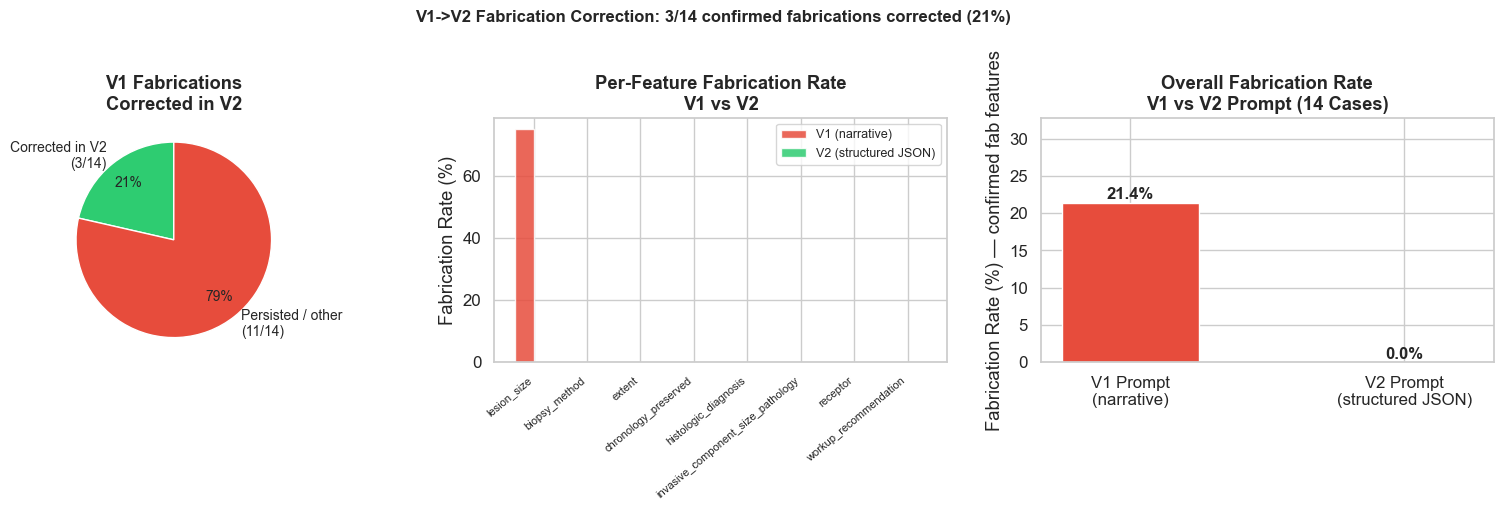

Saved: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\fab_v1_v2_pipeline_summary.png


In [7]:
COLORS = {'CORRECT': '#2ecc71', 'FABRICATION': '#e74c3c',
          'OMISSION': '#f39c12', 'TN': '#95a5a6'}

def annotation_label(ann):
    m = {1: 'CORRECT', 2: 'OMISSION', 3: 'FABRICATION', 'N/A': 'TN', None: 'UNKNOWN'}
    return m.get(ann, str(ann))

# Fig 1A: Pie - corrected vs persisted
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
n_persist = n_total - n_corrected
ax.pie(
    [n_corrected, n_persist],
    labels=[f'Corrected in V2\n({n_corrected}/{n_total})',
            f'Persisted / other\n({n_persist}/{n_total})'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 10}, pctdistance=0.75,
)
ax.set_title('V1 Fabrications\nCorrected in V2', fontweight='bold')

# Fig 1B: Per-feature fabrication rate V1 vs V2
ax = axes[1]
fab_sum = feat_metrics.sort_values('v1_fab_rate', ascending=False)
x = np.arange(len(fab_sum))
w = 0.35
ax.bar(x - w/2, fab_sum['v1_fab_rate'] * 100, w,
       label='V1 (narrative)', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, fab_sum['v2_fab_rate'] * 100, w,
       label='V2 (structured JSON)', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(fab_sum['feature'], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Fabrication Rate (%)')
ax.set_title('Per-Feature Fabrication Rate\nV1 vs V2', fontweight='bold')
ax.legend(fontsize=9)

# Fig 1C: Overall fabrication rate V1 vs V2
ax = axes[2]
v1_rate = agg_v1['overall_fabrication_rate'] * 100
v2_rate = agg_v2['overall_fabrication_rate'] * 100
bar_vals = [v1_rate, v2_rate]
bar_colors = ['#e74c3c', '#2ecc71' if v2_rate < v1_rate * 0.5 else '#f39c12']
bars = ax.bar(['V1 Prompt\n(narrative)', 'V2 Prompt\n(structured JSON)'],
              bar_vals, color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(bar_vals) * 1.3 + 5)
ax.set_ylabel('Fabrication Rate (%) — confirmed fab features')
ax.set_title('Overall Fabrication Rate\nV1 vs V2 Prompt (14 Cases)', fontweight='bold')

plt.suptitle(
    f'V1->V2 Fabrication Correction: {n_corrected}/{n_total} confirmed fabrications corrected '
    f'({100*n_corrected/max(n_total,1):.0f}%)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
fig1_path = REPORTS_DIR / 'fab_v1_v2_pipeline_summary.png'
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig1_path}')

C:\Users\jamesr4\AppData\Local\Temp\ipykernel_36784\2241246568.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  index=cases, columns=features).fillna(False).astype(float)
C:\Users\jamesr4\AppData\Local\Temp\ipykernel_36784\2241246568.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  index=cases, columns=features).fillna(False).astype(float)


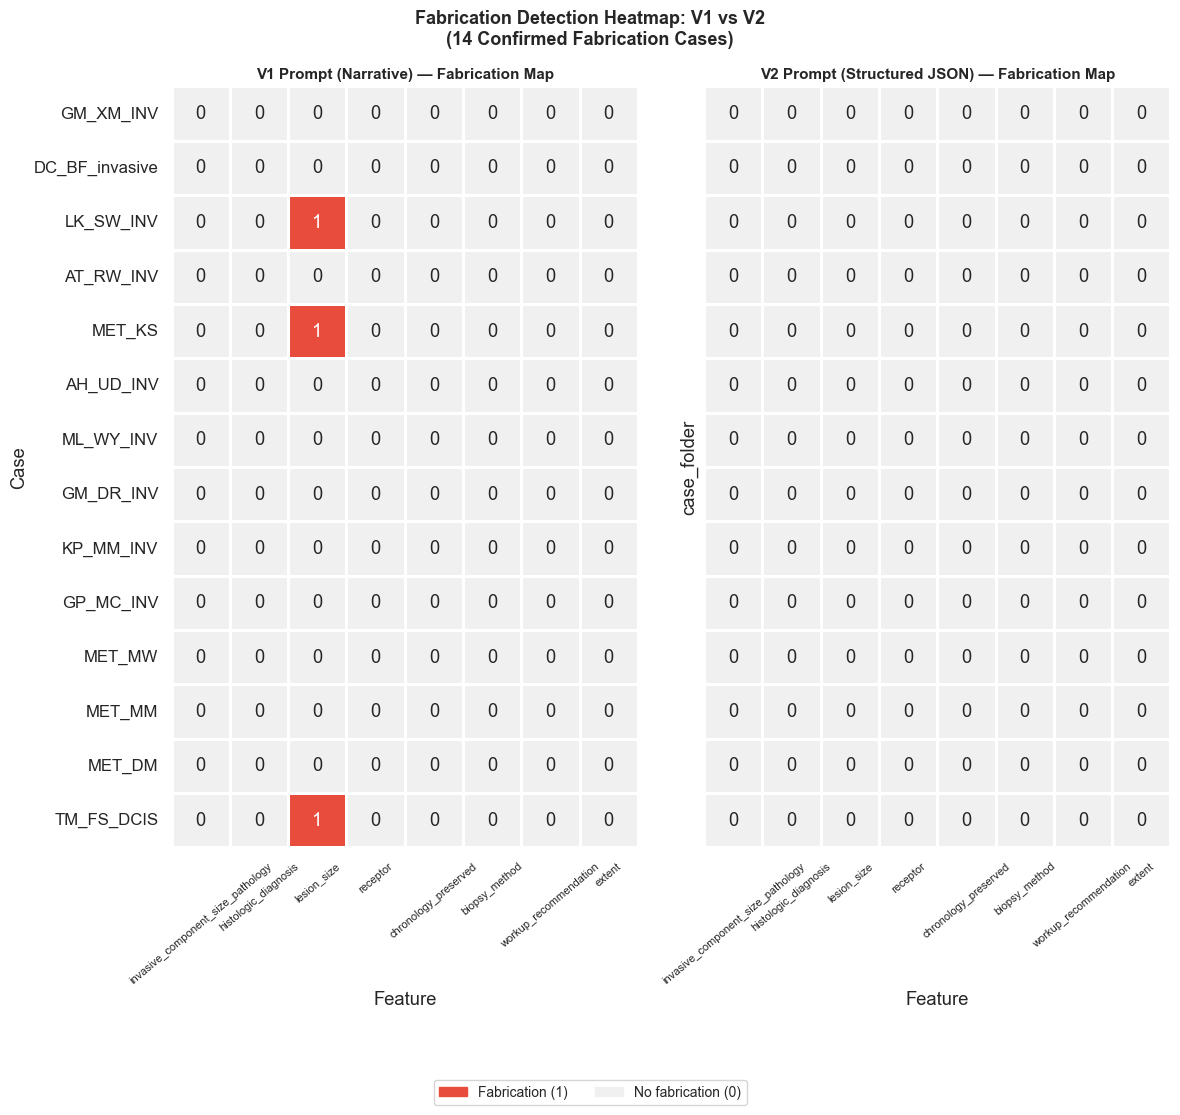

Saved: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\fab_v1_v2_heatmap.png


In [8]:
# ── Fig 2: Per-case × feature heatmap (V1 | V2 side-by-side) ─────────────────
features = comp_df['feature'].unique()
cases    = comp_df['case_folder'].unique()

v1_heat = comp_df.pivot_table(index='case_folder', columns='feature',
                               values='v1_fabrication', aggfunc='first').reindex(
    index=cases, columns=features).fillna(False).astype(float)
v2_heat = comp_df.pivot_table(index='case_folder', columns='feature',
                               values='v2_fabrication', aggfunc='first').reindex(
    index=cases, columns=features).fillna(False).astype(float)

fig2, axes2 = plt.subplots(1, 2, figsize=(max(12, len(features) * 1.4), max(5, len(cases) * 0.6 + 2)),
                            sharey=True)

for ax, heat, title in zip(
    axes2,
    [v1_heat, v2_heat],
    ['V1 Prompt (Narrative) — Fabrication Map', 'V2 Prompt (Structured JSON) — Fabrication Map']
):
    sns.heatmap(
        heat, ax=ax,
        cmap=['#f0f0f0', '#e74c3c'],
        vmin=0, vmax=1,
        linewidths=0.8, linecolor='white',
        cbar=False,
        annot=True, fmt='.0f',
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature')
    ax.tick_params(axis='x', rotation=40, labelsize=8)

axes2[0].set_ylabel('Case')

# Add colorbar legend
red_patch = mpatches.Patch(color='#e74c3c', label='Fabrication (1)')
wht_patch = mpatches.Patch(color='#f0f0f0', label='No fabrication (0)')
fig2.legend(handles=[red_patch, wht_patch], loc='lower center', ncol=2,
            fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Fabrication Detection Heatmap: V1 vs V2\n(14 Confirmed Fabrication Cases)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig2_path = REPORTS_DIR / 'fab_v1_v2_heatmap.png'
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig2_path}')

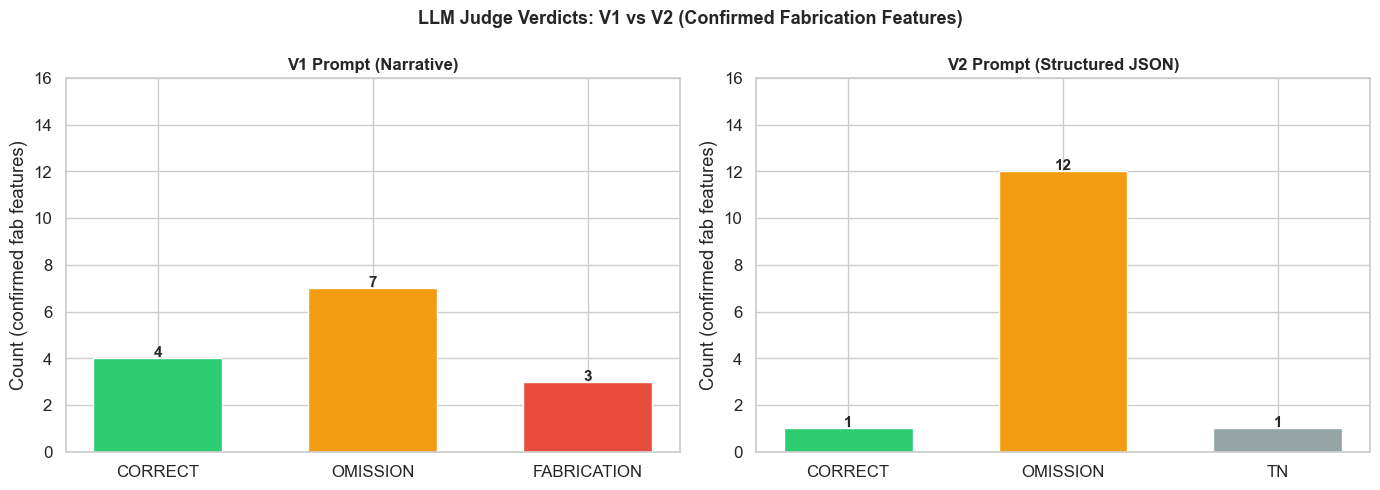

Saved: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\fab_v1_v2_annotation_distribution.png


In [9]:
# Fig 3: V1 vs V2 verdict distribution across confirmed-fab features (stacked bar)
comp_df['v1_label'] = comp_df['v1_annotation'].apply(annotation_label)
comp_df['v2_label'] = comp_df['v2_annotation'].apply(annotation_label)

order = ['CORRECT', 'OMISSION', 'FABRICATION', 'TN', 'UNKNOWN']
pal   = {'CORRECT': '#2ecc71', 'OMISSION': '#f39c12',
         'FABRICATION': '#e74c3c', 'TN': '#95a5a6', 'UNKNOWN': '#bdc3c7'}

v1_dist = comp_df['v1_label'].value_counts().reindex(order, fill_value=0)
v2_dist = comp_df['v2_label'].value_counts().reindex(order, fill_value=0)

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, dist, title in zip(
    axes3,
    [v1_dist, v2_dist],
    ['V1 Prompt (Narrative)', 'V2 Prompt (Structured JSON)'],
):
    bars = ax.bar(
        [l for l in order if dist[l] > 0],
        [dist[l] for l in order if dist[l] > 0],
        color=[pal[l] for l in order if dist[l] > 0],
        edgecolor='white', width=0.6,
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                str(int(h)), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Count (confirmed fab features)')
    ax.set_ylim(0, n_total + 2)

plt.suptitle('LLM Judge Verdicts: V1 vs V2 (Confirmed Fabrication Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig3_path = REPORTS_DIR / 'fab_v1_v2_annotation_distribution.png'
plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig3_path}')

In [10]:
# Save validation sheet (Excel, deepeval pipeline format)
excel_path = DEEPEVAL_OUT / 'fab_v1_v2_validation_sheet.xlsx'
met_rows = feat_metrics.to_dict('records')
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    comp_df.to_excel(writer, sheet_name='Fabrication_Comparison', index=False)
    pd.DataFrame(met_rows).to_excel(writer, sheet_name='Metrics_Summary', index=False)
    pd.DataFrame([{
        'prompt_version': 'V1', **agg_v1,
    }, {
        'prompt_version': 'V2', **agg_v2,
    }]).to_excel(writer, sheet_name='Aggregate', index=False)

print(f'Validation sheet saved: {excel_path}')
print()
print('=' * 60)
print('PIPELINE COMPLETE')
print('=' * 60)
print(f'Phase 1  source features : {FEAT_OUT}')
print(f'Phase 3  validation sheet: {excel_path}')
print(f'Figures  reports/        : fab_v1_v2_*.png')
print()
print(f'  V1 fabrication rate: {agg_v1["overall_fabrication_rate"]:.1%}')
print(f'  V2 fabrication rate: {agg_v2["overall_fabrication_rate"]:.1%}')
print(f'  Confirmed fab. corrected in V2: {n_corrected}/{n_total} '
      f'({100*n_corrected/max(n_total,1):.0f}%)')

Validation sheet saved: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\data\processed\deepeval_runs\fab_v1_v2\fab_v1_v2_validation_sheet.xlsx

PIPELINE COMPLETE
Phase 1  source features : C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\data\processed\source_doc_features_v3_simple
Phase 3  validation sheet: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\data\processed\deepeval_runs\fab_v1_v2\fab_v1_v2_validation_sheet.xlsx
Figures  reports/        : fab_v1_v2_*.png

  V1 fabrication rate: 21.4%
  V2 fabrication rate: 0.0%
  Confirmed fab. corrected in V2: 3/14 (21%)
